In this notebook we explore the question "Why current flows at all?". We consider two dimensional motion of charged (ideal) particles that start out at random positions based on a uniform distribution in a box of a given width and height. Their initial velocities are chosen at random based on normal distribution. 



In [7]:
import numpy as np
import matplotlib.pyplot as plt

Current essentially is a balance: Electric field trying to accelerate electrons.
Scattering trying to randomize them. That balance creates a constant drift velocity, which is exactly what we'll simulate.

We first define our box's geomtery and limit particle number to make our lives easier.

In [8]:
N = 500          # Number of electrons
width = 10       # Box width
height = 5       # Box height
dt = 0.05       # Time step for simulation to know how long to evolve

We put in charge values. m is mass, q is charge
We also put in the value of applied electric field that causes the charges to move. 

In [9]:
q = -1 #coulomb
m = 1 #kg
Ex = 10 #volts

ax = q * Ex / m

Initial Positions and velocities

In [10]:
x = np.random.uniform(0, width, N)
y = np.random.uniform(0, height, N)

vx = np.random.normal(0, 1, N)
vy = np.random.normal(0, 1, N)


In [11]:
drift = []
P = 0.2

for step in range(500):

   
    #accelerate electrons
    vx += ax * dt 

    #move electrons about
    x += vx * dt
    y += vy * dt

    #beriodic boundaries
    x = x % width
    y = y % height


    # Collisions
    collision = np.random.rand(N) < P
    vx[collision] = np.random.normal(0, 1, np.sum(collision))
    vy[collision] = np.random.normal(0, 1, np.sum(collision))


    drift.append(np.mean(vx))

   

In [12]:
print(np.mean(vx))

-1.848720800001582


The distribution below will look differnent every time the loop aboove is run, due the randomization of collisions, velocity and position values. This is important for consistency of the code with respect to real physics.

Average vx: -1.848720800001582
Average vy: 0.02098539124855033


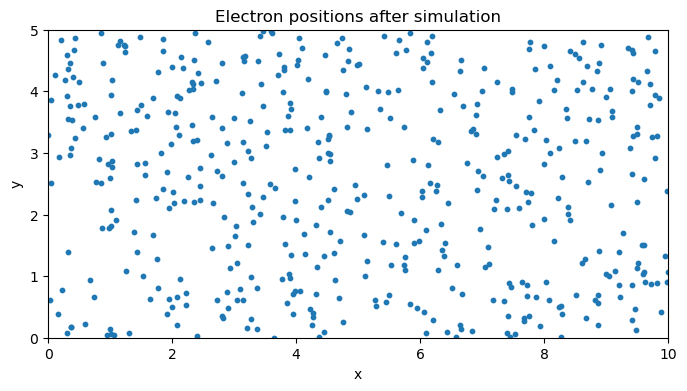

In [13]:
print("Average vx:", np.mean(vx))
print("Average vy:", np.mean(vy))

plt.figure(figsize=(8,4))
plt.scatter(x, y, s=10)
plt.xlim(0, width)
plt.ylim(0, height)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Electron positions after simulation")
plt.show()

Plotting drift velocity

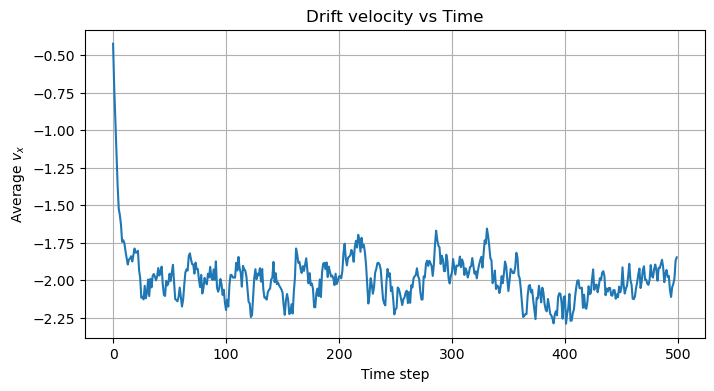

In [14]:
plt.figure(figsize=(8,4))
plt.plot(drift)
plt.xlabel("Time step")
plt.ylabel("Average $v_x$")
plt.title("Drift velocity vs Time")
plt.grid(True)
plt.show()

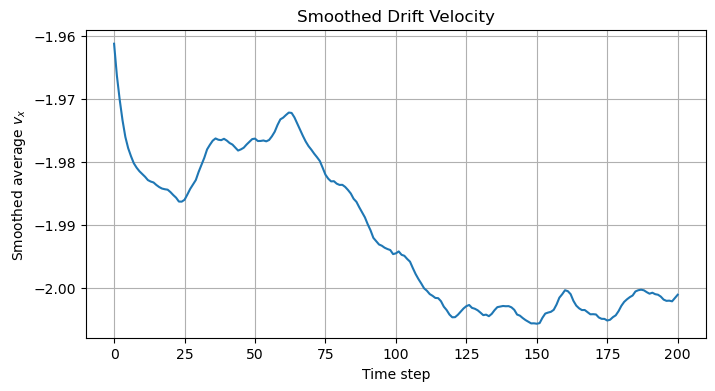

In [15]:
window = 300
smooth = np.convolve(drift, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8,4))
plt.plot(smooth)
plt.xlabel("Time step")
plt.ylabel("Smoothed average $v_x$")
plt.title("Smoothed Drift Velocity")
plt.grid(True)
plt.show()